# Sesión 1: Regresión en Física (Modelado de Magnitudes Continuas)
**Facilitador: Héctor Martínez | Unidad de Telecomunicaciones - ABAE**

Este cuaderno interactivo guiará los experimentos prácticos del primer bloque del taller. Abordaremos tres problemas progresivos diseñados para entender desde la unidad matemática elemental (la neurona) hasta estructuras de capas profundas aptas para aproximar funciones no lineales complejas.

## Objetivos de Aprendizaje:
1. Comprender el rol del peso ($w$) y el sesgo ($b$) mediante una relación lineal pura.
2. Identificar el impacto de las capas ocultas y funciones de activación (ReLU).
3. Diseñar una arquitectura multivariable evaluando su convergencia con curvas de pérdida (Loss Curves).

In [2]:
# Importación del ecosistema de desarrollo para IA
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print("Versión de TensorFlow en ejecución:", tf.__version__)

Versión de TensorFlow en ejecución: 2.20.0


## 1. Calibración del Sensor de Temperatura de un Satélite (Telemetry Counts a °C)
**Propósito:** Comprender los conceptos de peso ($w$) y sesgo ($b$) aislando el ruido analítico.

Los sistemas de telemetría espacial reciben datos crudos en variables digitales conocidas como *Counts*. La relación física para convertirlos a grados Celsius responde a una calibración puramente lineal:
$$\text{Temperatura (°C)} = w \cdot \text{Counts} + b$$

Entrenaremos una sola neurona para que "descubra" la ganancia ($w$) y el offset ($b$) óptimos basándose únicamente en mediciones históricas, simulando que no poseemos la hoja de datos de calibración del fabricante.

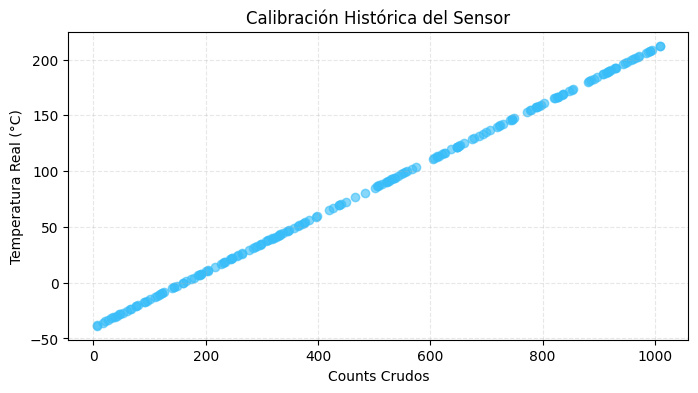

In [39]:
# ==========================================
# ACA EL MODELO FISICO A EMULAR!
# Ecuación real subyacente: Temp = 0.25 * Counts - 40.0

# Simulación de lecturas históricas (Relación lineal exacta oculta)
np.random.seed(42)
counts_train = np.random.uniform(0, 1023, 200) # ADC de 10 bits
temp_train = 0.25 * counts_train - 40.0
# ==========================================

# Visualización inicial del comportamiento del sensor
plt.figure(figsize=(8, 4))
plt.scatter(counts_train, temp_train, color='#38bdf8', alpha=0.6, label='Datos de Telemetría')
plt.title('Calibración Histórica del Sensor')
plt.xlabel('Counts Crudos')
plt.ylabel('Temperatura Real (°C)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [64]:
# ==========================================
# ETAPA A: DEFINICIÓN ARQUITECTÓNICA DE LA RED
# ==========================================
# Una sola capa densa con 1 nodo y entrada unidimensional
model_sensor = keras.Sequential([
    keras.Input(shape=(1,)), # Recommended way to define input shape
    keras.layers.Dense(units=1)
])

print("Resumen de la arquitectura diseñada:")
model_sensor.summary()

# ==========================================
# ETAPA B: PREPARACIÓN PARA LA COMPILACIÓN
# ==========================================
# Configuración del optimizador (Adam) y la función de pérdida para regresión (MSE)
model_sensor.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.5), # Tasa alta debido a la simplicidad del problema
    loss='mean_squared_error'
)

# Entrenamiento del modelo lineal
print("\nIniciando ajuste de calibración autónomo...")
history_sensor = model_sensor.fit(counts_train, temp_train, epochs=60, verbose=0)
print("¡Entrenamiento finalizado exitosamente!")

Resumen de la arquitectura diseñada:


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)


Iniciando ajuste de calibración autónomo...
¡Entrenamiento finalizado exitosamente!


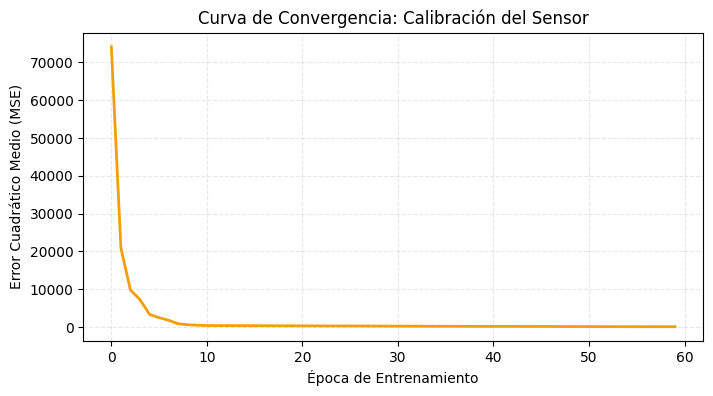

In [50]:
# Visualización de la convergencia para la calibración del sensor (Sección 1)
plt.figure(figsize=(8, 4))
plt.plot(history_sensor.history['loss'], color='#f59e0b', lw=2)
plt.title('Curva de Convergencia: Calibración del Sensor')
plt.xlabel('Época de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [51]:
# Extracción de los parámetros que la neurona aprendió de forma autónoma
pesos, sesgo = model_sensor.get_weights()
print(f"--> Parámetro w (Peso aprendido por la red): {pesos[0][0]:.4f}  (Valor real teórico: 0.25)")
print(f"--> Parámetro b (Sesgo/Offset aprendido):  {sesgo[0]:.4f} (Valor real teórico: -40.0)")

print('\nAcá el array completo:\n')
print(model_sensor.get_weights())

--> Parámetro w (Peso aprendido por la red): 0.2319  (Valor real teórico: 0.25)
--> Parámetro b (Sesgo/Offset aprendido):  -26.2494 (Valor real teórico: -40.0)

Acá el array completo:

[array([[0.23191978]], dtype=float32), array([-26.249386], dtype=float32)]


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


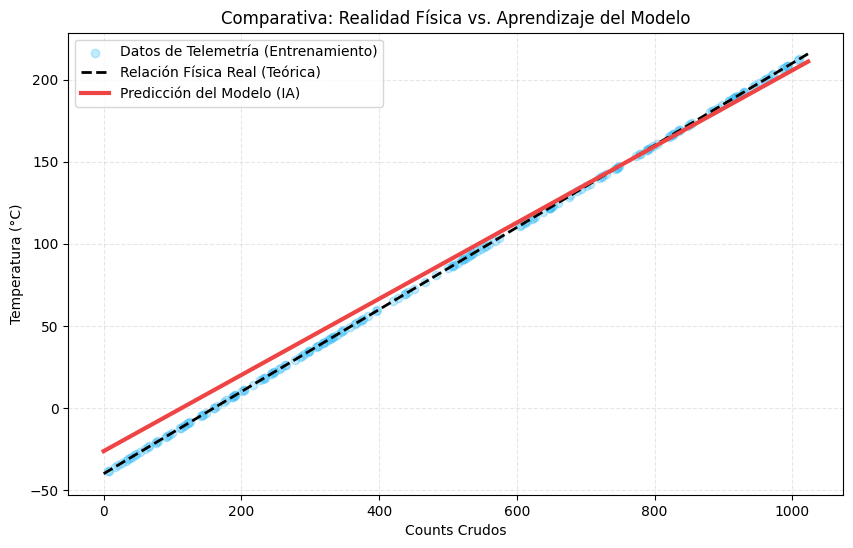

In [52]:
# Generación de datos para la comparación visual
counts_test = np.linspace(0, 1023, 100).reshape(-1, 1)
temp_teorica = 0.25 * counts_test - 40.0
temp_predicha = model_sensor.predict(counts_test)

# Creación del gráfico de solapamiento
plt.figure(figsize=(10, 6))

# 1. Muestras originales de entrenamiento
plt.scatter(counts_train, temp_train, color='#38bdf8', alpha=0.3, label='Datos de Telemetría (Entrenamiento)')

# 2. Curva Teórica (La física real)
plt.plot(counts_test, temp_teorica, color='black', linestyle='--', lw=2, label='Relación Física Real (Teórica)')

# 3. Curva Predicha (Lo que aprendió la IA)
plt.plot(counts_test, temp_predicha, color='#ef4444', lw=3, label='Predicción del Modelo (IA)')

plt.title('Comparativa: Realidad Física vs. Aprendizaje del Modelo')
plt.xlabel('Counts Crudos')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## 2. Atenuación de Señal en Telecomunicaciones por Pérdida en el Espacio Libre (FSPL)
**Propósito:** Demostrar el impacto de las capas ocultas y funciones de activación cuando la física deja de ser lineal.

La pérdida de potencia de una señal de radiofrecuencia (en dB) a medida que un satélite se desplaza respecto a la estación terrena sigue la ley de la inversa del cuadrado de la distancia. Al expresarse en escala logarítmica, el comportamiento describe una curva. Una neurona lineal simple fallará rotundamente (*underfitting*).

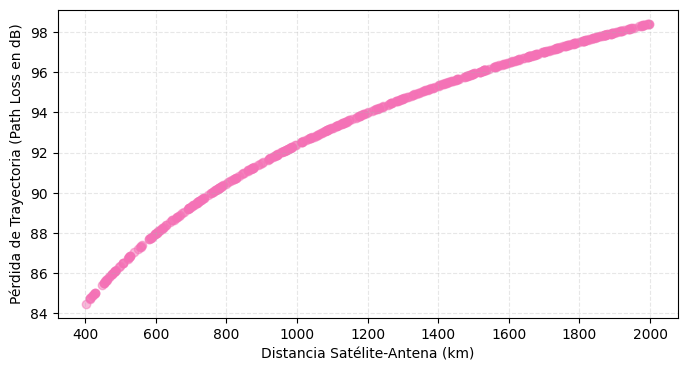

In [5]:
# Simulación de pérdida de trayectoria (Curva logarítmica física)
distancia_train = np.random.uniform(400, 2000, 500) # Kilómetros (Órbita LEO)
# Ecuación física simplificada: FSPL(dB) = 20*log10(d) + Constante
path_loss_train = 20 * np.log10(distancia_train) + 32.4

plt.figure(figsize=(8, 4))
plt.scatter(distancia_train, path_loss_train, color='#f472b6', alpha=0.5, label='Muestras RF')
plt.xlabel('Distancia Satélite-Antena (km)')
plt.ylabel('Pérdida de Trayectoria (Path Loss en dB)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### 2.1 Usando **`ReLU`**

In [67]:
# ==========================================
# ETAPA A: DEFINICIÓN ARQUITECTÓNICA DE LA RED
# ==========================================
model_rf = keras.Sequential([
    keras.Input(shape=(1,)), # Recommended way to define input shape
    keras.layers.Dense(units=2),
    keras.layers.Dense(units=1)
])

print("Resumen de la arquitectura diseñada:")
model_rf.summary()

# ==========================================
# ETAPA B: PREPARACIÓN PARA LA COMPILACIÓN
# ==========================================
model_rf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='mean_squared_error',
    metrics=['mean_absolute_error'] # Métrica de validación humana complementaria
)

# Ejecución del entrenamiento de la estructura profunda
print("\nIniciando ajuste de calibración autónomo...")
history_rf = model_rf.fit(distancia_train, path_loss_train, epochs=60, verbose=0)
print("¡Modelo de telecomunicaciones aproximado con éxito!")

Resumen de la arquitectura diseñada:


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_43 (Dense)                │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)


Iniciando ajuste de calibración autónomo...
¡Modelo de telecomunicaciones aproximado con éxito!


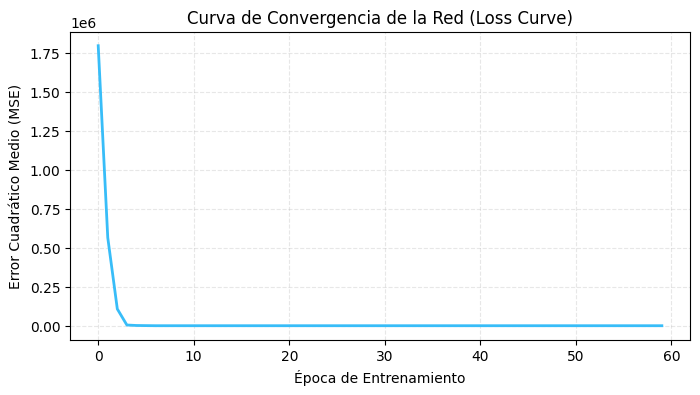

In [68]:
# Graficar la reducción del error a través de las iteraciones (Épocas)
plt.figure(figsize=(8, 4))
plt.plot(history_rf.history['loss'], color='#38bdf8', lw=2)
plt.title('Curva de Convergencia de la Red (Loss Curve)')
plt.xlabel('Época de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


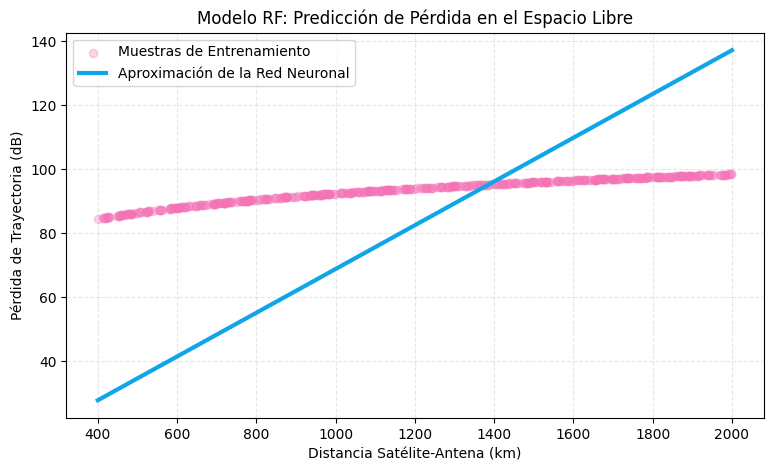

In [69]:
# Generación de predicciones para el modelo de Radiofrecuencia (Sección 2)
distancia_test = np.linspace(400, 2000, 300).reshape(-1, 1)
predicciones_rf = model_rf.predict(distancia_test)

# Visualización de resultados
plt.figure(figsize=(9, 5))
plt.scatter(distancia_train, path_loss_train, color='#f472b6', alpha=0.3, label='Muestras de Entrenamiento')
plt.plot(distancia_test, predicciones_rf, color='#0ea5e9', lw=3, label='Aproximación de la Red Neuronal')
plt.title('Modelo RF: Predicción de Pérdida en el Espacio Libre')
plt.xlabel('Distancia Satélite-Antena (km)')
plt.ylabel('Pérdida de Trayectoria (dB)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [70]:
# Inspección detallada de parámetros por cada capa del modelo RF
print(f"Análisis de parámetros para: {model_rf.name}\n")
print(f'\nCapa: {model_rf.layers[0].name}:\n')
print(model_rf.layers[0].get_weights())
print(f'\nCapa: {model_rf.layers[1].name}:\n')
print(model_rf.layers[1].get_weights())

Análisis de parámetros para: sequential_18


Capa: dense_43:

[array([[ 1.4666417 , -0.54118645]], dtype=float32), array([-1.2982367 ,  0.05746816], dtype=float32)]

Capa: dense_44:

[array([[-0.29550597],
       [-0.92732704]], dtype=float32), array([0.01712991], dtype=float32)]


### 2.2 Usando **`softplus`**

In [29]:
# ==========================================
# ETAPA A: DEFINICIÓN ARQUITECTÓNICA DE LA RED
# ==========================================
model_rf = keras.Sequential([
    # Usamos 'softplus' para que la red maneje las distancias de miles sin morir
    keras.Input(shape=(1,)), # Recommended way to define input shape

    keras.layers.Dense(units=32, activation='softplus'),
    keras.layers.Dense(units=32, activation='softplus'),
    keras.layers.Dense(units=16, activation='softplus'),
    keras.layers.Dense(units=1)
])

# ==========================================
# ETAPA B: PREPARACIÓN PARA LA COMPILACIÓN
# ==========================================
model_rf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='mean_squared_error',
    metrics=['mean_absolute_error'] # Métrica de validación humana complementaria
)

# Ejecución del entrenamiento de la estructura profunda
history_rf = model_rf.fit(distancia_train, path_loss_train, epochs=500, verbose=0)
print("¡Modelo de telecomunicaciones aproximado con éxito!")

¡Modelo de telecomunicaciones aproximado con éxito!


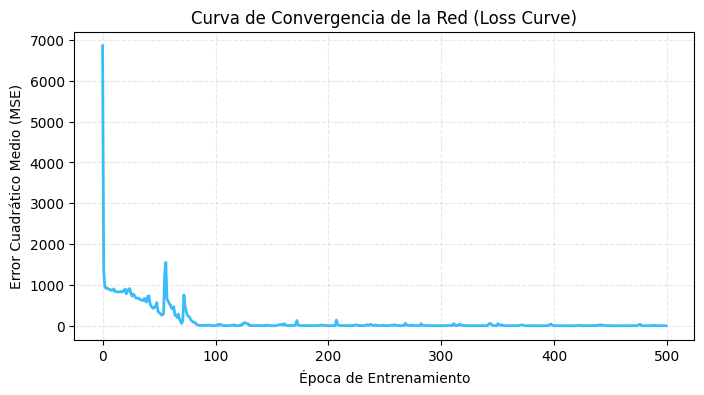

In [30]:
# Graficar la reducción del error a través de las iteraciones (Épocas)
plt.figure(figsize=(8, 4))
plt.plot(history_rf.history['loss'], color='#38bdf8', lw=2)
plt.title('Curva de Convergencia de la Red (Loss Curve)')
plt.xlabel('Época de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


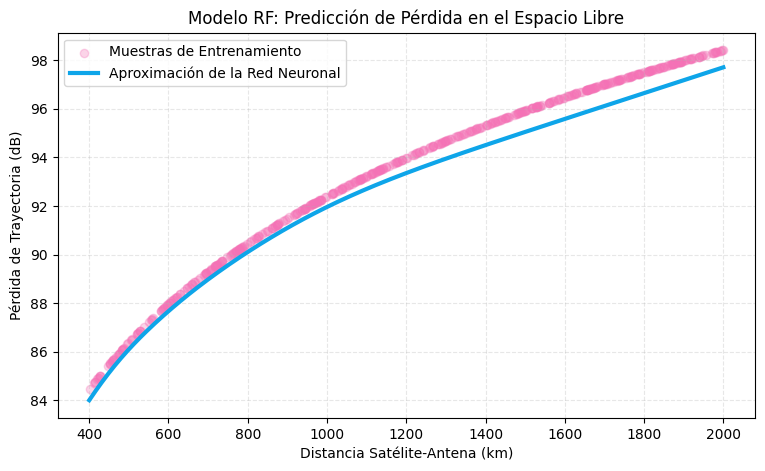

In [31]:
# Generación de predicciones para el modelo de Radiofrecuencia (Sección 2)
distancia_test = np.linspace(400, 2000, 300).reshape(-1, 1)
predicciones_rf = model_rf.predict(distancia_test)

# Visualización de resultados
plt.figure(figsize=(9, 5))
plt.scatter(distancia_train, path_loss_train, color='#f472b6', alpha=0.3, label='Muestras de Entrenamiento')
plt.plot(distancia_test, predicciones_rf, color='#0ea5e9', lw=3, label='Aproximación de la Red Neuronal')
plt.title('Modelo RF: Predicción de Pérdida en el Espacio Libre')
plt.xlabel('Distancia Satélite-Antena (km)')
plt.ylabel('Pérdida de Trayectoria (dB)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()